In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

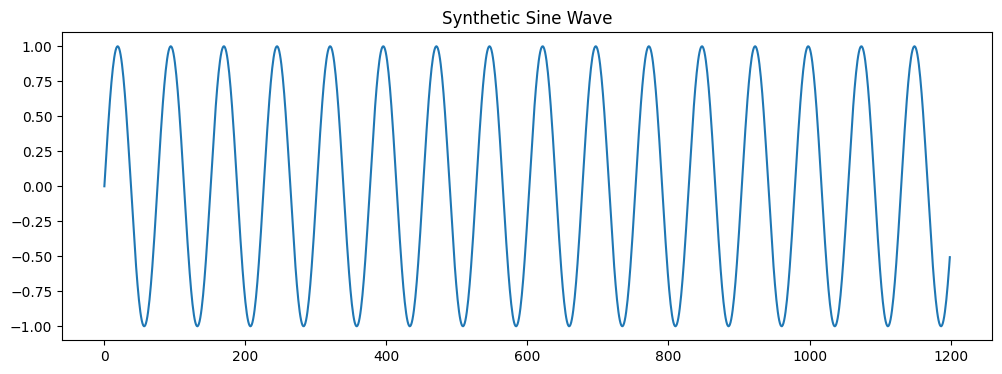

In [ ]:
# Generate sine wave

x = np.linspace(0, 100, 1200)
y = np.sin(x)

plt.figure(figsize=(12,4))
plt.plot(y)
plt.title("Synthetic Sine Wave")
plt.show()

In [ ]:
sequence_length = 20

X = []
Y = []

for i in range(len(y)-sequence_length):
    X.append(y[i:i+sequence_length])
    Y.append(y[i+sequence_length])

X = np.array(X)
Y = np.array(Y)

print("Input Shape:", X.shape)
print("Output Shape:", Y.shape)

Input Shape: (1180, 20)
Output Shape: (1180,)


In [ ]:
X = X.reshape((X.shape[0], X.shape[1], 1))

print(X.shape)

(1180, 20, 1)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    shuffle=False
)

In [ ]:
model = Sequential()

model.add(SimpleRNN(
    50,
    activation='tanh',
    input_shape=(sequence_length,1)
))

model.add(Dense(25, activation='relu'))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,901 (15.24 KB)

 Trainable params: 3,901 (15.24 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0582 - mae: 0.1658 - val_loss: 0.0058 - val_mae: 0.0606
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0032 - mae: 0.0461 - val_loss: 0.0011 - val_mae: 0.0280
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.0320e-04 - mae: 0.0216 - val_loss: 3.0772e-04 - val_mae: 0.0143
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.9934e-04 - mae: 0.0108 - val_loss: 1.2896e-04 - val_mae: 0.0088
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.1891e-05 - mae: 0.0071 - val_loss: 6.9606e-05 - val_mae: 0.0061
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.8612e-05 - mae: 0.0050 - val_loss: 4.3627e-05 - val_mae: 0.0045
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.6502e-05 - mae: 0.0043 - val_loss: 3.6418e-05 - val_mae: 0.0044
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.0320e-05 - mae: 0.0040 - val_loss: 3.0201e-05 - val_mae: 0.0041
Epoch 9/30
24/24 ━━━━━━

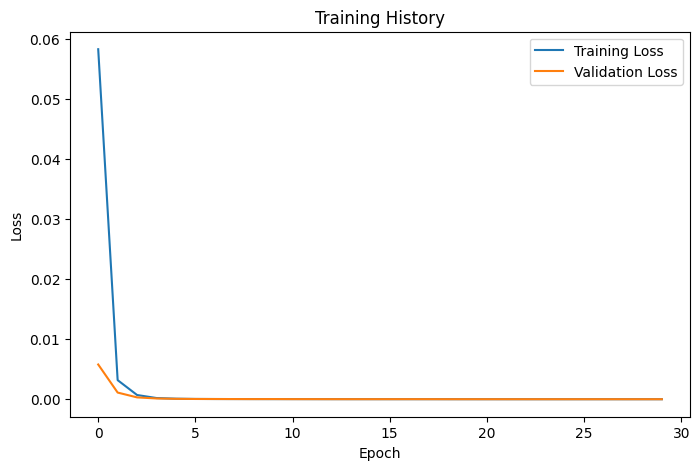

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
predictions = model.predict(X_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [ ]:
mse = mean_squared_error(y_test, predictions)

print("Mean Squared Error:", mse)

Mean Squared Error: 2.592914253037993e-06


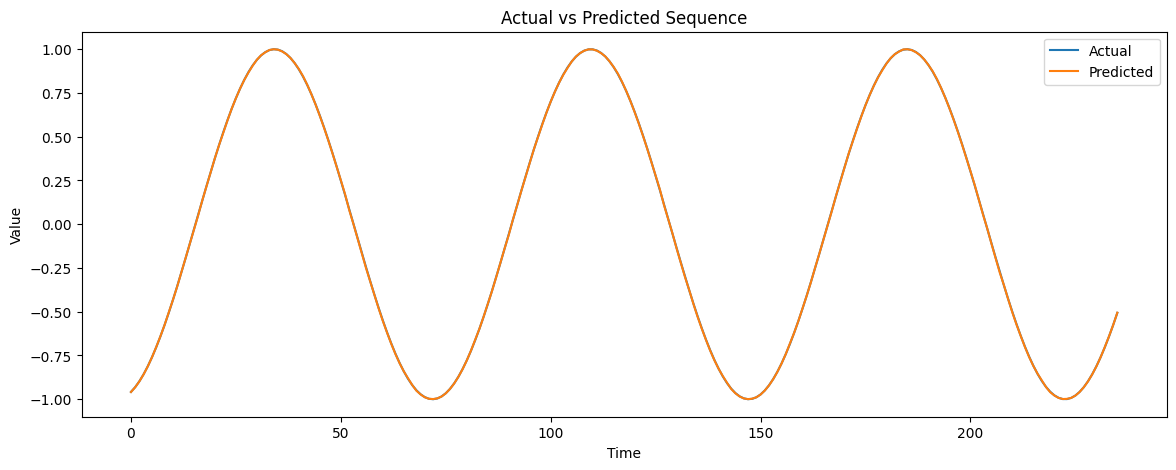

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(y_test, label='Actual')
plt.plot(predictions, label='Predicted')

plt.title("Actual vs Predicted Sequence")
plt.xlabel("Time")
plt.ylabel("Value")

plt.legend()
plt.show()

In [ ]:
last_sequence = y[-sequence_length:]

last_sequence = last_sequence.reshape((1, sequence_length, 1))

next_value = model.predict(last_sequence)

print("Predicted Next Value:", next_value[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted Next Value: -0.43281293
